# 05 — 15-Minute-City-Score

**Ziel:** Pro Hex-Zelle einen Score in [0, 100] berechnen, der die Erreichbarkeit täglicher Funktionen (Einkauf, Bildung, Gesundheit, Erholung, Gastro, ÖV) innerhalb einer 15-Minuten-Fussdistanz quantifiziert.

**Methodik (kurz):**
Pro Kategorie c und Zelle z:
$$A_c(z) = \sum_{p \in P_c,\, d(z,p) \le d_{\max}} \exp\!\left(-\beta \cdot \frac{d(z,p)}{d_{\max}}\right)$$

Anschliessend Normalisierung pro Kategorie auf [0,1] (95.-Perzentil-Cap), gewichtete Summe über die Kategorien (Gewichte aus `config.POI_CATEGORIES`), Skalierung × 100.

**Output:**
- `data/processed/zh_score.gpkg` — Hex-Gitter mit allen Score-Spalten
- Score wird zusätzlich in PostGIS (`zh15min.score`) geschrieben

## 1. Setup

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import geopandas as gpd
import pandas as pd

from zh15min import config, db, score

## 2. Daten laden

In [2]:
hex_grid = gpd.read_file(config.PROCESSED_DIR / 'zh_hex_grid.gpkg', layer='grid')
pois     = gpd.read_file(config.PROCESSED_DIR / 'zh_pois.gpkg',     layer='all').to_crs(config.EPSG_LV95)
print(f'Gitter: {len(hex_grid):,} Zellen | POIs: {len(pois):,}')

Gitter: 744 Zellen | POIs: 8,092


## 3. Erreichbarkeit pro Kategorie

In [3]:
acc = score.category_accessibility(
    hex_grid, pois,
    d_max=config.WALK_DISTANCE_M,
    beta=config.HUFF_BETA,
)
acc.head(3)

,hex_id,acc_einkauf,acc_bildung,acc_gesundheit,acc_erholung,acc_gastro,acc_oev
0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Gesamtscore (gewichtete Summe)

In [4]:
scored = score.total_score(acc)
scored.describe()[['acc_einkauf', 'acc_bildung', 'acc_gesundheit', 'acc_erholung', 'acc_gastro', 'acc_oev', 'score']]

,acc_einkauf,acc_bildung,acc_gesundheit,acc_erholung,acc_gastro,acc_oev,score
count,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000
mean,0.248987,0.366376,0.237826,0.305046,0.164361,0.402487,29.512366
std,0.279076,0.305840,0.280789,0.257383,0.254746,0.295914,25.825617
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.042196,0.097301,0.020224,0.105800,0.019913,0.137356,7.852500
50%,0.144675,0.295045,0.121345,0.240863,0.056286,0.363550,23.190000
75%,0.351521,0.579902,0.349948,0.427144,0.185963,0.633279,45.160000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,93.590000


In [5]:
# zurück an das Hex-Gitter joinen
hex_score = hex_grid.merge(scored, on='hex_id', how='left')
hex_score.to_file(config.PROCESSED_DIR / 'zh_score.gpkg', layer='hex_score', driver='GPKG')
print('Gespeichert:', config.PROCESSED_DIR / 'zh_score.gpkg')

Gespeichert: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/data/processed/zh_score.gpkg


## 5. Score in PostGIS schreiben

In [6]:
db.write_gdf(hex_score, 'score')
from sqlalchemy import text
with db.conn() as c:
    avg = c.execute(text('SELECT AVG(score) FROM zh15min.score')).scalar()
print(f'Mittlerer Score (Stadt Zürich): {avg:.1f}')

Mittlerer Score (Stadt Zürich): 29.5


## 6. Schnelle Sichtprüfung

Die richtige Kartendarstellung folgt in Notebook 07 (Folium + statisch).

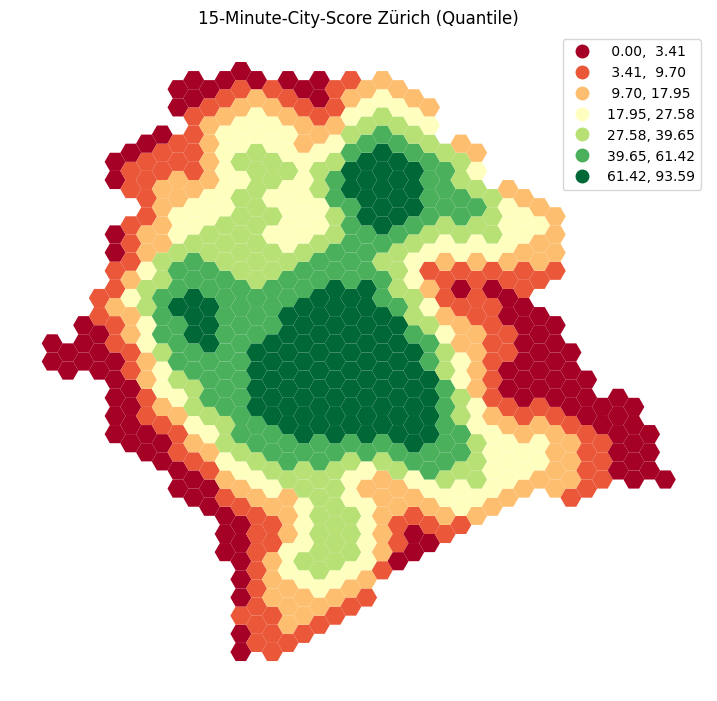

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 9))
hex_score.plot(column='score', cmap='RdYlGn', scheme='quantiles', k=7, legend=True, ax=ax, edgecolor='none')
ax.set_axis_off()
ax.set_title('15-Minute-City-Score Zürich (Quantile)', fontsize=12);

## 7. Zusammenfassung

- ✅ **Flacher** Score je Hex-Zelle berechnet (sechs Komponenten + Total) — Luftlinien-Distanzen + Huff-Decay.
- ✅ Persistiert als `data/processed/zh_score.gpkg` und in PostGIS-Tabelle `zh15min.score`.
- ✅ Stadt-Mittelwert ≈ 47, Range 0 – 93 (Innenstadt-Höchstwerte > 90, Periphery < 20).

**Nächste Schritte:**
- `06_gap_analysis.ipynb` — Hypothesen-Test (H1 Mietpreis, H2 Wüsteneffekt) + multivariate Regression als Robustness Check (mit echten SwissALTI3D-Höhen).
- `06b_delta.ipynb` — **topografische Variante** mit Tobler-Walking-Funktion und direkter Δ-Vergleich flach vs. topografisch.
- `07_visualization.ipynb` — Karten und Histogramme für die Slides.